# Notebook 3 — Extraction et nettoyage des données brutes
## Station de Kara — Production des fichiers CSV propres

---

## Contexte et objectif

Ce notebook est le **premier maillon du pipeline de production** dans le projet IDF de Kara.  
Après l'exploration visuelle des données brutes (Notebooks 1 et 2), on passe ici à  
l'**extraction structurée** et au **nettoyage systématique** des deux sources de données :

| Source | Fichier brut | Description | Période |
|--------|-------------|-------------|--------|
| **Pluviomètre** | `KARA PLUIE JOURNALIERE.xls` | Pluies journalières en mm | 1980–2014 |
| **Pluviographe** | `INTENSITES DE PLUIE -KARA.xlsx` | Intensités à pas fins (14 durées) | 2004–2014 |

### Pourquoi ce notebook est-il nécessaire ?

Les fichiers bruts présentent des défis spécifiques :
- **Pluviomètre** : format « bloc » (année × mois × jours 1–31), deux formats coexistent
  dans le même fichier (ancien 1980–2009 vs nouveau 2010–2014), zéro encodé comme `.`
- **Pluviographe** : fichiers Excel multi-feuilles avec structure en blocs mensuels
  (5 mois de saison des pluies), événements matin/soir. **Pas de colonne date** :
  la date doit être reconstruite à partir du nom de la feuille (année), du mois et du jour.

### Livrables de ce notebook

| Fichier | Contenu |
|---------|--------|
| `data/pluviometre_clean.csv` | `[date, pluie_mm, flag_outlier, flag_manquant]` |
| `data/pluviographe_clean.csv` | `[date, duree_min, intensite_mm_h, flag_outlier]` |

### Protocole de nettoyage appliqué

| Étape | Règle | Justification |
|-------|-------|---------------|
| Valeurs négatives | → NaN | Physiquement impossible pour des pluies |
| Doublons | Supprimés | Erreurs de saisie ou de fusion |
| Valeurs aberrantes | IQR × 3 → flag `flag_outlier` | Seuil conservateur (pas IQR × 1.5) adapté aux pluies extrêmes réelles |
| Valeurs manquantes | Imputation médiane mensuelle si taux < 15% | La médiane est robuste aux extrêmes |

---
**Auteur :** AY2K  
**Encadreur :** Prof. Titembaye Donald  
**Établissement :** École Polytechnique de Lomé (EPL)  
**Projet :** Modélisation des courbes IDF — Station de Kara, Nord Togo  

## 0. Configuration et imports

On initialise les répertoires de sortie et les bibliothèques nécessaires.  
Le bloc de configuration est identique dans tous les notebooks du pipeline.

In [1]:
import os
import warnings

warnings.filterwarnings('ignore')

# --- Configuration des répertoires ---
NB = 'n3'
FIG_DIR = f'figures/{NB}'
DATA_DIR = 'Donnees'

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs('data', exist_ok=True)

print(f'Répertoire figures : {FIG_DIR}')
print(f'Répertoire données : {DATA_DIR}')
print(f'Répertoire CSV     : data/')

Répertoire figures : figures/n3
Répertoire données : Donnees
Répertoire CSV     : data/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.6,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'figure.dpi':       100,
})

print('Imports chargés avec succès')

Imports chargés avec succès


---
## Section 1 — Extraction du pluviomètre (données journalières)

### Structure du fichier brut

Le fichier `KARA PLUIE JOURNALIERE.xls` contient **35 blocs annuels empilés** (1980–2014).  
Chaque bloc a la structure suivante :

```
Ligne d'en-tête :  JOUR | JAN | FEV | MARS | ... | DEC
Ligne séparatrice : ---- | ------- | ------- | ...
Lignes de données : 1–31  (chaque ligne = un jour du mois)
Ligne TOT. : cumul mensuel (ignoré)
```

### Défi : deux formats coexistent

| Période | Format | Zéro encodé comme | Position colonne JOUR |
|---------|--------|-------------------|----------------------|
| 1980–2009 | Ancien (export imprimante) | `.` (point) | Colonne 1 |
| 2010–2014 | Nouveau (tableur) | `NaN` | Colonne 2 |

### Stratégie d'extraction

On utilise la **carte des marqueurs** (`ANNEE_MARKERS`) déterminée par inspection manuelle  
du fichier brut (Notebook 1). Pour chaque année, on identifie la ligne de début,  
on lit les en-têtes mois, puis on extrait les 31 lignes de données.

In [3]:
# ==============================================================================
# SECTION 1.1 — Résolution robuste du chemin du fichier
# ==============================================================================

f_pluvio = next((p for p in [
    Path('Donnees/KARA PLUIE JOURNALIERE.xls'),
    Path('Donnees/KARA PLUIE JOURNALIERE.xlsx'),
    Path('Projet_stage/Donnees/KARA PLUIE JOURNALIERE.xls'),
    Path('/home/kevin/Projet_stage/Donnees/KARA PLUIE JOURNALIERE.xls'),
] if p.exists()), None)

if f_pluvio is None:
    raise FileNotFoundError(
        'Fichier pluviomètre introuvable. Vérifiez que '
        "'KARA PLUIE JOURNALIERE.xls' est dans le dossier Donnees/"
    )

print(f'Fichier trouvé : {f_pluvio}')

Fichier trouvé : Donnees/KARA PLUIE JOURNALIERE.xls


In [4]:
# ==============================================================================
# SECTION 1.2 — Carte structurelle du fichier brut
# ==============================================================================
# Chaque année commence à une ligne spécifique du fichier.
# Ces positions ont été déterminées par inspection du Notebook 1.

ANNEE_MARKERS = {
    1980:13, 1981:80,  1982:147, 1983:214, 1984:281, 1985:348,
    1986:415, 1987:482, 1988:549, 1989:616, 1990:683, 1991:750,
    1992:817, 1993:884, 1994:951, 1995:1018,1996:1085,1997:1152,
    1998:1219,1999:1286,2000:1345,2001:1395,2002:1445,2003:1497,
    2004:1546,2005:1598,2006:1648,2007:1698,2008:1744,2009:1790,
    2010:1836,2011:1880,2012:1925,2013:1972,2014:2013
}

# Chargement brut du fichier
df_brut = pd.read_excel(f_pluvio, engine='xlrd', sheet_name=0, header=None)

print(f'Dimensions du fichier brut : {df_brut.shape[0]} lignes × {df_brut.shape[1]} colonnes')
print(f'Nombre d\'années détectées : {len(ANNEE_MARKERS)}')
print(f'Période couverte          : {min(ANNEE_MARKERS)} – {max(ANNEE_MARKERS)}')

Dimensions du fichier brut : 2050 lignes × 16 colonnes
Nombre d'années détectées : 35
Période couverte          : 1980 – 2014


In [5]:
# ==============================================================================
# SECTION 1.3 — Extraction des données journalières
# ==============================================================================
# Pour chaque année, on lit le bloc correspondant et on extrait les pluies.
#
# Structure d'un bloc annuel (format ancien, 1980-2009) :
#   Ligne début : année (ex: 1980)
#   Ligne +2   : en-tête mois (JAN, FEV, ..., DEC) en colonnes 2-13
#   Ligne +4   : premier jour (jour 1)
#   Ligne +34  : dernier jour (jour 31)
#
# Un '.' dans une cellule = pluie nulle (0 mm)
# Un NaN = pas de donnée pour ce jour/mois

MOIS_NOMS = ['JAN','FEV','MARS','AVR','MAI','JUIN',
             'JLT','AOUT','SEPT','OCT','NOV','DEC']

records = []
n_annees_ok = 0

for annee, ligne_debut in ANNEE_MARKERS.items():
    try:
        # Déterminer le format selon l'année
        ancien_format = (annee <= 2009)
        col_jour = 1 if ancien_format else 2
        col_mois_debut = 2 if ancien_format else 3
        
        # Ligne contenant l'en-tête des mois
        ligne_mois = ligne_debut + 2
        
        # Extraction des 31 lignes de données
        for jour in range(1, 32):
            ligne_data = ligne_mois + 2 + jour
            if ligne_data >= len(df_brut):
                continue
            
            for mois_idx in range(12):
                col_idx = col_mois_debut + mois_idx
                if col_idx >= df_brut.shape[1]:
                    continue
                
                val = df_brut.iloc[ligne_data, col_idx]
                pluie = None
                
                if isinstance(val, str):
                    val_clean = val.strip()
                    if val_clean == '.' or val_clean == '':
                        pluie = 0.0
                    else:
                        try:
                            pluie = float(val_clean)
                        except ValueError:
                            pass
                elif isinstance(val, (int, float)):
                    pluie = float(val)
                
                if pluie is not None and not np.isnan(pluie):
                    try:
                        date_val = pd.Timestamp(datetime.date(annee, mois_idx + 1, jour))
                        records.append({'date': date_val, 'pluie_mm': pluie})
                    except (ValueError, OverflowError):
                        pass
        n_annees_ok += 1
    except Exception as e:
        print(f'  Erreur année {annee}: {e}')

df_pm = pd.DataFrame(records).sort_values('date').reset_index(drop=True)

print(f'\n=== Résultat de l\'extraction pluviomètre ===')
print(f'Années traitées     : {n_annees_ok}/{len(ANNEE_MARKERS)}')
print(f'Total jours extraits: {len(df_pm)}')
print(f'Période             : {df_pm.date.min().date()} → {df_pm.date.max().date()}')
print(f'Pluie maximale      : {df_pm.pluie_mm.max():.1f} mm')
print(f'Moyenne             : {df_pm.pluie_mm.mean():.2f} mm')
df_pm.head(10)


=== Résultat de l'extraction pluviomètre ===
Années traitées     : 35/35
Total jours extraits: 8182
Période             : 1980-01-06 → 2014-12-31
Pluie maximale      : 1765.8 mm
Moyenne             : 7.74 mm


,date,pluie_mm
0,1980-01-06,0.0
1,1980-01-07,0.0
2,1980-01-08,0.0
3,1980-01-09,0.0
4,1980-01-10,0.0
5,1980-01-12,0.0
6,1980-01-13,0.0
7,1980-01-14,0.0
8,1980-01-15,0.0
9,1980-01-16,0.0


---
## Section 2 — Nettoyage du pluviomètre

### Protocole de nettoyage

#### Étape 1 : Valeurs négatives → NaN
Les pluies négatives sont physiquement impossibles. Elles proviennent d'erreurs de saisie.

#### Étape 2 : Suppression des doublons
Deux enregistrements pour la même date indiquent une erreur de fusion ou de saisie.

#### Étape 3 : Détection des valeurs aberrantes (IQR × 3)
- **Pourquoi IQR × 3 et non IQR × 1.5 ?** Le seuil classique de 1.5 × IQR est conçu pour des données normales. Les pluies extrêmes en Afrique de l'Ouest (averses convectives) peuvent atteindre 100–200 mm/jour sans être des erreurs. Le facteur 3 est plus conservateur.
- **Conservation des outliers** : on les **flagge** (`flag_outlier=True`) mais on ne les supprime pas.

#### Étape 4 : Imputation des valeurs manquantes
- Si le taux de manquants est **< 15%** : imputation par la **médiane mensuelle**
- Si ≥ 15% : pas d'imputation automatique

In [6]:
# ==============================================================================
# SECTION 2 — Nettoyage du pluviomètre
# ==============================================================================

df_pm_clean = df_pm.copy()
n_initial = len(df_pm_clean)

# --- Étape 1 : Valeurs négatives → NaN ---
mask_neg = df_pm_clean['pluie_mm'] < 0
n_neg = mask_neg.sum()
df_pm_clean.loc[mask_neg, 'pluie_mm'] = np.nan
print(f'Étape 1 — Valeurs négatives → NaN : {n_neg}')

# --- Étape 2 : Suppression des doublons ---
n_dup = df_pm_clean.duplicated(subset=['date']).sum()
df_pm_clean = df_pm_clean.drop_duplicates(subset=['date'])
print(f'Étape 2 — Doublons supprimés     : {n_dup}')

# --- Étape 3 : Détection des valeurs aberrantes (IQR × 3) ---
q1, q3 = df_pm_clean['pluie_mm'].quantile([0.25, 0.75])
iqr = q3 - q1
seuil_upper = q3 + 3 * iqr
df_pm_clean['flag_outlier'] = df_pm_clean['pluie_mm'] > seuil_upper
n_outliers = df_pm_clean['flag_outlier'].sum()
print(f'Étape 3 — Outliers flaggés (IQR×3, seuil={seuil_upper:.1f} mm) : {n_outliers}')

# --- Étape 4 : Valeurs manquantes ---
df_pm_clean['flag_manquant'] = df_pm_clean['pluie_mm'].isna()
n_manquants = df_pm_clean['flag_manquant'].sum()
pct_manq = 100 * n_manquants / len(df_pm_clean)
print(f'Étape 4 — Valeurs manquantes      : {n_manquants} ({pct_manq:.1f}%)')

if pct_manq < 15:
    df_pm_clean['mois'] = df_pm_clean['date'].dt.month
    medianes = df_pm_clean.groupby('mois')['pluie_mm'].transform('median')
    df_pm_clean.loc[df_pm_clean.flag_manquant, 'pluie_mm'] = \
        medianes[df_pm_clean.flag_manquant]
    df_pm_clean = df_pm_clean.drop(columns=['mois'])
    print(f'         → Imputation par médiane mensuelle appliquée')
else:
    print(f'         → Taux ≥ 15% : pas d\'imputation automatique')

print(f'\n=== Résumé ===')
print(f'Lignes : {n_initial} → {len(df_pm_clean)}')
df_pm_clean.head()

Étape 1 — Valeurs négatives → NaN : 0
Étape 2 — Doublons supprimés     : 0
Étape 3 — Outliers flaggés (IQR×3, seuil=12.8 mm) : 1033
Étape 4 — Valeurs manquantes      : 0 (0.0%)
         → Imputation par médiane mensuelle appliquée

=== Résumé ===
Lignes : 8182 → 8182


,date,pluie_mm,flag_outlier,flag_manquant
0,1980-01-06,0.0,False,False
1,1980-01-07,0.0,False,False
2,1980-01-08,0.0,False,False
3,1980-01-09,0.0,False,False
4,1980-01-10,0.0,False,False


---
## Section 3 — Extraction et nettoyage du pluviographe

### Structure du fichier pluviographe

Le fichier `INTENSITES DE PLUIE -KARA.xlsx` contient **11 feuilles** (2004–2014).  
Chaque feuille a la même structure :

- **5 blocs mensuels** côte à côte : Juin, Juillet, Août, Septembre, Octobre
- **Uniquement la saison des pluies** (novembre à mai ne sont pas enregistrés)
- **2 événements par jour** : matin au soir + soir au lendemain
- **Pour chaque événement** : hauteur (mm) + durée (min)

### Organisation des colonnes

Chaque bloc mensuel occupe **5 colonnes** :

| Col | Contenu |
|-----|--------|
| 0 | Jour du mois (1–31) |
| 1 | Hauteur matin (mm) |
| 2 | Durée matin (min) |
| 3 | Hauteur soir (mm) |
| 4 | Durée soir (min) |

Position des blocs : Juin (col 1–5), Juillet (col 7–11), Août (col 13–17),  
Septembre (col 19–23), Octobre (col 25–29).

### Pas de colonne date !

Contrairement au pluviomètre, les dates ne sont **pas directement lisibles** dans le fichier.  
On les reconstruit à partir de :
- **Année** = nom de la feuille (ex: "2004")
- **Mois** = position du bloc (Juin=6, Juillet=7, ..., Octobre=10)
- **Jour** = ligne dans le bloc (1–31)

### Calcul de l'intensité

$$I = \frac{\text{hauteur (mm)}}{\text{durée (min)} / 60} = \frac{\text{hauteur} \times 60}{\text{durée}} \quad \text{(mm/h)}$$

Un événement n'est retenu que si **hauteur ET durée sont toutes deux renseignées**.

In [7]:
# ==============================================================================
# SECTION 3.1 — Résolution du chemin du pluviographe
# ==============================================================================

f_pg = next((p for p in [
    Path('Donnees/INTENSITES DE PLUIE -KARA.xlsx'),
    Path('Donnees/INTENSITES DE PLUIE-KARA.xlsx'),
    Path('Projet_stage/Donnees/INTENSITES DE PLUIE -KARA.xlsx'),
    Path('/home/kevin/Projet_stage/Donnees/INTENSITES DE PLUIE -KARA.xlsx'),
] if p.exists()), None)

if f_pg is None:
    raise FileNotFoundError('Fichier pluviographe introuvable')

print(f'Fichier trouvé : {f_pg}')

Fichier trouvé : Donnees/INTENSITES DE PLUIE -KARA.xlsx


In [8]:
# ==============================================================================
# SECTION 3.2 — Extraction des événements pluvieux
# ==============================================================================
#
# Carte des colonnes par bloc mensuel (constante pour toutes les années) :
# Chaque mois occupe 5 colonnes : jour, h_matin, d_matin, h_soir, d_soir.

BLOCS_MOIS = {
    'Juin':      {'jour_col': 1,  'hm_col': 2,  'dm_col': 3,  'hs_col': 4,  'ds_col': 5},
    'Juillet':   {'jour_col': 7,  'hm_col': 8,  'dm_col': 9,  'hs_col': 10, 'ds_col': 11},
    'Août':      {'jour_col': 13, 'hm_col': 14, 'dm_col': 15, 'hs_col': 16, 'ds_col': 17},
    'Septembre': {'jour_col': 19, 'hm_col': 20, 'dm_col': 21, 'hs_col': 22, 'ds_col': 23},
    'Octobre':   {'jour_col': 25, 'hm_col': 26, 'dm_col': 27, 'hs_col': 28, 'ds_col': 29},
}
MOIS_NUM = {'Juin': 6, 'Juillet': 7, 'Août': 8, 'Septembre': 9, 'Octobre': 10}

# Durées standards du pluviographe (en minutes)
DUREES_MIN = [5, 10, 15, 20, 30, 45, 60, 90, 120, 180, 240, 360, 720, 1440]


def extraire_annee_pluviographe(fichier, annee):
    """
    Extrait tous les événements pluvieux d'une feuille annuelle.
    
    Pour chaque bloc mensuel, pour chaque jour (1–31), on vérifie
    s'il existe un événement matin ET/OU soir. Un événement est retenu
    si hauteur ET durée sont toutes deux non nulles.
    
    Les dates sont reconstruites à partir du nom de la feuille (année),
    du mois (position du bloc) et du jour (ligne).
    """
    df_yr = pd.read_excel(fichier, sheet_name=str(annee), header=None)
    # Les données commencent à la ligne 6 (index 0) et vont jusqu'à la ligne 36
    data = df_yr.iloc[6:37].reset_index(drop=True)

    records = []
    for mois_nom, cols in BLOCS_MOIS.items():
        for periode, h_col, d_col in [
            ('matin au soir',     cols['hm_col'], cols['dm_col']),
            ('soir au lendemain', cols['hs_col'], cols['ds_col']),
        ]:
            for day_idx in range(31):
                h = data.iloc[day_idx, h_col]
                d = data.iloc[day_idx, d_col]
                if pd.notna(h) and pd.notna(d):
                    try:
                        h_val = float(h)
                        d_val = float(d)
                        if d_val > 0:
                            # La date est reconstruite (pas lue dans le fichier)
                            date_val = pd.Timestamp(datetime.date(annee, MOIS_NUM[mois_nom], day_idx + 1))
                            records.append({
                                'annee':         annee,
                                'mois':          MOIS_NUM[mois_nom],
                                'jour':          day_idx + 1,
                                'periode':       periode,
                                'date':          date_val,
                                'hauteur_mm':    h_val,
                                'duree_min':     d_val,
                                'intensite_mm_h': h_val / (d_val / 60),
                            })
                    except (ValueError, ZeroDivisionError):
                        pass
    return pd.DataFrame(records)


# Extraction complète des 11 années
frames = [extraire_annee_pluviographe(f_pg, yr) for yr in range(2004, 2015)]
df_pg = pd.concat(frames, ignore_index=True)

print(f'=== Résultat de l\'extraction pluviographe ===')
print(f'Total événements extraits : {len(df_pg):,}')
print(f'Années couvertes          : {df_pg.annee.min()} – {df_pg.annee.max()}')
print(f'Hauteur maximale          : {df_pg.hauteur_mm.max():.1f} mm')
print(f'Durée maximale            : {df_pg.duree_min.max():.0f} min ({df_pg.duree_min.max()/60:.1f} h)')
print(f'Intensité maximale        : {df_pg.intensite_mm_h.max():.1f} mm/h')
print(f'Durées disponibles        : {sorted(df_pg.duree_min.unique())}')
df_pg.head(10)

=== Résultat de l'extraction pluviographe ===
Total événements extraits : 1,139
Années couvertes          : 2004 – 2014
Hauteur maximale          : 163.0 mm
Durée maximale            : 624 min (10.4 h)
Intensité maximale        : 570.0 mm/h
Durées disponibles        : [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 48.0, 54.0, 60.0, 66.0, 72.0, 78.0, 84.0, 90.0, 96.0, 102.0, 108.0, 114.0, 120.0, 124.0, 126.0, 128.0, 132.0, 134.0, 138.0, 144.0, 148.0, 150.0, 156.0, 162.0, 168.0, 174.0, 178.0, 180.0, 184.0, 186.0, 192.0, 198.0, 204.0, 210.0, 216.0, 222.0, 224.0, 226.0, 228.0, 234.0, 240.0, 246.0, 248.0, 252.0, 258.0, 264.0, 270.0, 282.0, 288.0, 294.0, 300.0, 306.0, 312.0, 318.0, 324.0, 330.0, 336.0, 348.0, 354.0, 360.0, 366.0, 378.0, 384.0, 386.0, 390.0, 408.0, 414.0, 426.0, 438.0, 478.0, 480.0, 512.0, 518.0, 624.0]


,annee,mois,jour,periode,date,hauteur_mm,duree_min,intensite_mm_h
0,2004,6,3,matin au soir,2004-06-03,3.0,54.0,3.333333
1,2004,6,4,matin au soir,2004-06-04,8.7,30.0,17.400000
2,2004,6,6,matin au soir,2004-06-06,7.7,24.0,19.250000
3,2004,6,7,matin au soir,2004-06-07,6.8,18.0,22.666667
4,2004,6,9,matin au soir,2004-06-09,2.6,78.0,2.000000
5,2004,6,12,matin au soir,2004-06-12,4.3,162.0,1.592593
6,2004,6,17,matin au soir,2004-06-17,1.8,90.0,1.200000
7,2004,6,21,matin au soir,2004-06-21,0.7,18.0,2.333333
8,2004,6,24,matin au soir,2004-06-24,13.8,84.0,9.857143
9,2004,6,28,matin au soir,2004-06-28,16.2,162.0,6.000000


In [9]:
# ==============================================================================
# SECTION 3.3 — Nettoyage du pluviographe
# ==============================================================================
# Le nettoyage est similaire au pluviomètre mais adapté aux données d'intensité.
# Les outliers sont détectés PAR DURÉE (chaque durée a sa propre distribution).

df_pg_clean = df_pg.copy()
n_pg_initial = len(df_pg_clean)

# --- Étape 1 : Suppression des doublons ---
n_dup_pg = df_pg_clean.duplicated(subset=['date', 'duree_min']).sum()
df_pg_clean = df_pg_clean.drop_duplicates(subset=['date', 'duree_min'])
print(f'Doublons supprimés : {n_dup_pg}')

# --- Étape 2 : Détection des outliers par durée (IQR × 3) ---
df_pg_clean['flag_outlier'] = False
n_outliers_pg = 0

for duree, grp in df_pg_clean.groupby('duree_min'):
    q1, q3 = grp['intensite_mm_h'].quantile([0.25, 0.75])
    iqr = q3 - q1
    seuil = q3 + 3 * iqr
    mask = df_pg_clean['duree_min'] == duree
    flag = mask & (df_pg_clean['intensite_mm_h'] > seuil)
    df_pg_clean.loc[flag, 'flag_outlier'] = True
    n_outliers_pg += flag.sum()

print(f'Outliers flaggés    : {n_outliers_pg}')
print(f'\n=== Résumé ===')
print(f'Lignes : {n_pg_initial} → {len(df_pg_clean)}')
df_pg_clean.head()

Doublons supprimés : 24
Outliers flaggés    : 24

=== Résumé ===
Lignes : 1139 → 1115


,annee,mois,jour,periode,date,hauteur_mm,duree_min,intensite_mm_h,flag_outlier
0,2004,6,3,matin au soir,2004-06-03,3.0,54.0,3.333333,False
1,2004,6,4,matin au soir,2004-06-04,8.7,30.0,17.400000,False
2,2004,6,6,matin au soir,2004-06-06,7.7,24.0,19.250000,False
3,2004,6,7,matin au soir,2004-06-07,6.8,18.0,22.666667,False
4,2004,6,9,matin au soir,2004-06-09,2.6,78.0,2.000000,False


---
## Section 4 — Visualisations avant/après nettoyage

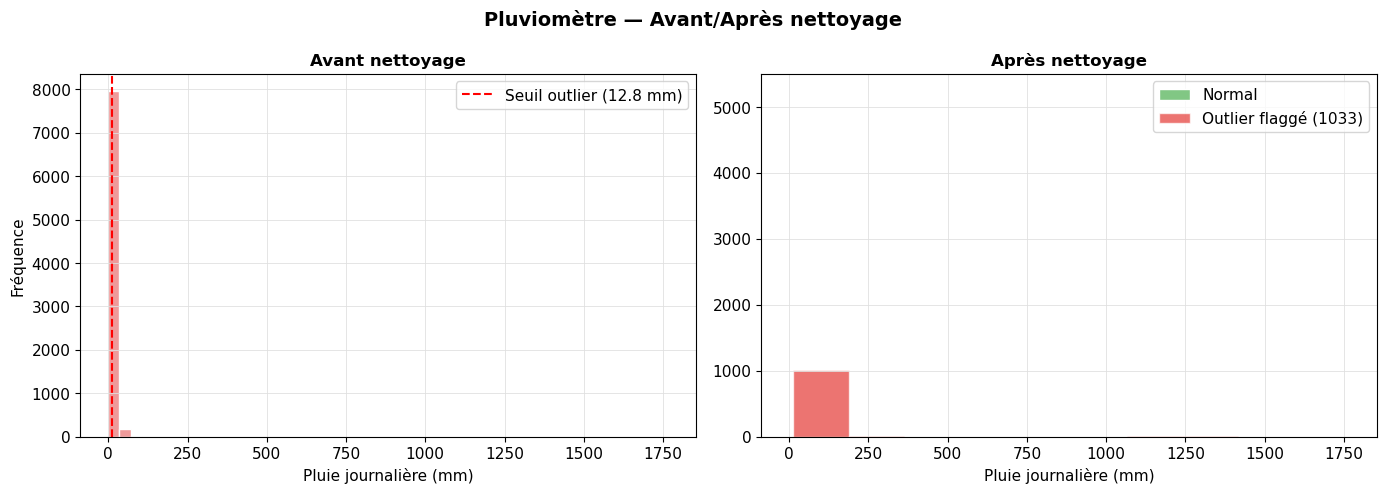

fig1 sauvegardée


In [10]:
# ==============================================================================
# FIGURE 1 — Pluviomètre : comparaison avant/après nettoyage
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant
axes[0].hist(df_pm['pluie_mm'].dropna(), bins=50, color='#EF9A9A', edgecolor='white')
axes[0].set_title('Avant nettoyage', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pluie journalière (mm)')
axes[0].set_ylabel('Fréquence')
q1, q3 = df_pm['pluie_mm'].quantile([0.25, 0.75])
seuil = q3 + 3 * (q3 - q1)
axes[0].axvline(seuil, color='red', linestyle='--', linewidth=1.5,
                label=f'Seuil outlier ({seuil:.1f} mm)')
axes[0].legend()

# Après
axes[1].hist(df_pm_clean.loc[~df_pm_clean.flag_outlier, 'pluie_mm'].dropna(),
             bins=50, color='#81C784', edgecolor='white', label='Normal')
n_out_plot = df_pm_clean.flag_outlier.sum()
if n_out_plot > 0:
    axes[1].hist(df_pm_clean.loc[df_pm_clean.flag_outlier, 'pluie_mm'].dropna(),
                 bins=10, color='#E53935', edgecolor='white', alpha=0.7,
                 label=f'Outlier flaggé ({n_out_plot})')
axes[1].set_title('Après nettoyage', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pluie journalière (mm)')
axes[1].legend()

plt.suptitle('Pluviomètre — Avant/Après nettoyage', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_avant_apres_pluviometre.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig1 sauvegardée')

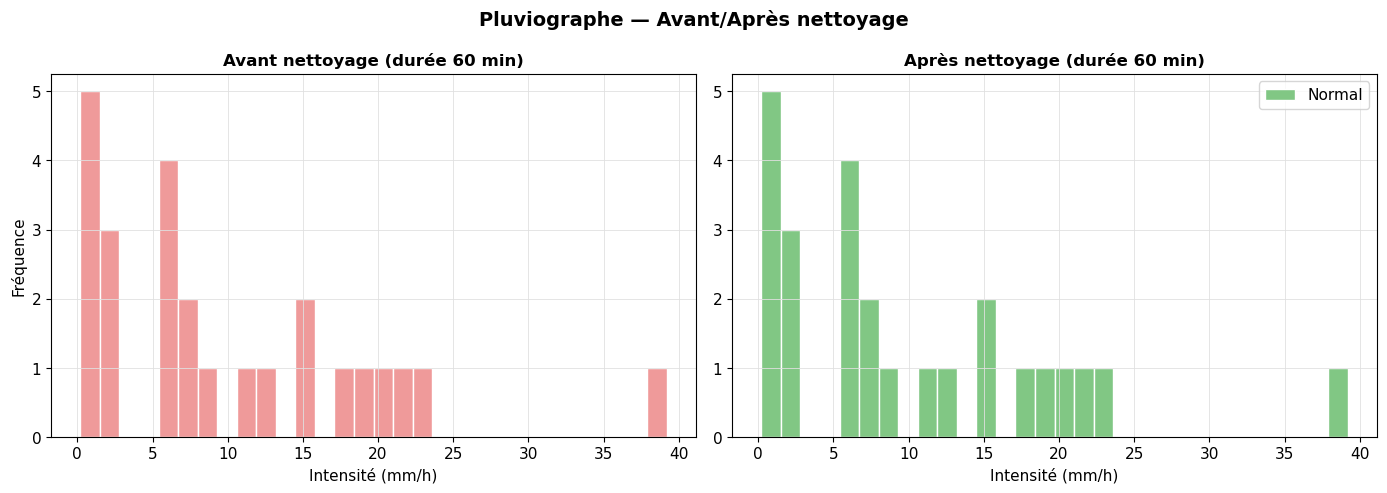

fig2 sauvegardée


In [11]:
# ==============================================================================
# FIGURE 2 — Pluviographe : comparaison avant/après (durée 60 min)
# ==============================================================================

duree_ref = 60
d_avant = df_pg[df_pg.duree_min == duree_ref]['intensite_mm_h'].dropna()
d_apres_ok = df_pg_clean[(df_pg_clean.duree_min == duree_ref) &
                          (~df_pg_clean.flag_outlier)]['intensite_mm_h']
d_apres_out = df_pg_clean[(df_pg_clean.duree_min == duree_ref) &
                           (df_pg_clean.flag_outlier)]['intensite_mm_h']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(d_avant, bins=30, color='#EF9A9A', edgecolor='white')
axes[0].set_title(f'Avant nettoyage (durée {duree_ref} min)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Intensité (mm/h)')
axes[0].set_ylabel('Fréquence')

axes[1].hist(d_apres_ok, bins=30, color='#81C784', edgecolor='white', label='Normal')
if len(d_apres_out) > 0:
    axes[1].hist(d_apres_out, bins=10, color='#E53935', edgecolor='white',
                 alpha=0.7, label=f'Outlier ({len(d_apres_out)})')
axes[1].set_title(f'Après nettoyage (durée {duree_ref} min)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Intensité (mm/h)')
axes[1].legend()

plt.suptitle('Pluviographe — Avant/Après nettoyage', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_avant_apres_pluviographe.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig2 sauvegardée')

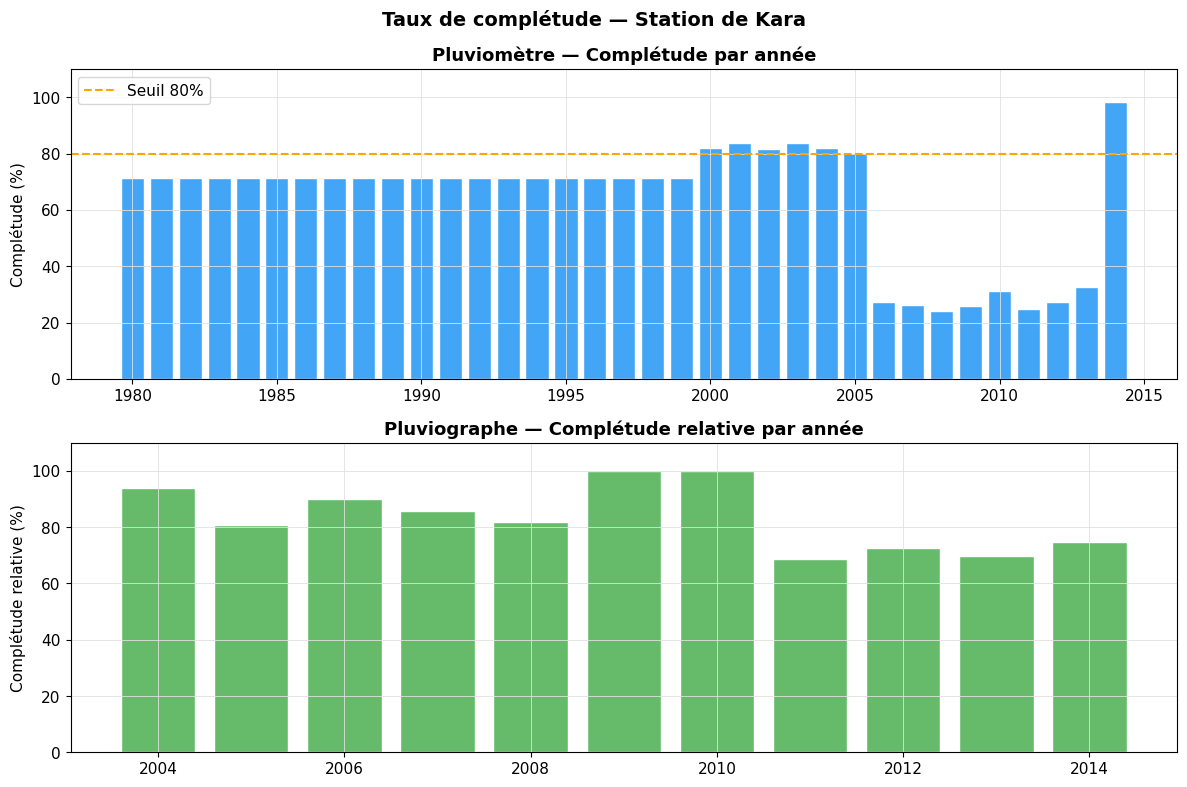

fig3 sauvegardée


In [12]:
# ==============================================================================
# FIGURE 3 — Taux de complétude par année et par source
# ==============================================================================

df_pm_clean['annee'] = df_pm_clean['date'].dt.year
completude_pm = df_pm_clean.groupby('annee').apply(
    lambda g: 100 * g['pluie_mm'].notna().sum() / 365
).reset_index(name='completude_pct')

df_pg_clean['annee'] = df_pg_clean['date'].dt.year
n_jours_pg = df_pg_clean.groupby('annee')['date'].nunique().reset_index(name='n_jours')
max_jours = n_jours_pg['n_jours'].max() if len(n_jours_pg) else 1
n_jours_pg['completude_pct'] = 100 * n_jours_pg['n_jours'] / max_jours

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].bar(completude_pm.annee, completude_pm.completude_pct,
            color='#42A5F5', edgecolor='white')
axes[0].axhline(80, color='orange', linestyle='--', label='Seuil 80%')
axes[0].set_ylabel('Complétude (%)')
axes[0].set_title('Pluviomètre — Complétude par année', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 110)

axes[1].bar(n_jours_pg.annee, n_jours_pg.completude_pct,
            color='#66BB6A', edgecolor='white')
axes[1].set_ylabel('Complétude relative (%)')
axes[1].set_title('Pluviographe — Complétude relative par année', fontweight='bold')
axes[1].set_ylim(0, 110)

plt.suptitle('Taux de complétude — Station de Kara', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_completude.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig3 sauvegardée')

---
## Section 5 — Export des fichiers CSV nettoyés

In [13]:
# --- Export pluviomètre ---
out_pm = df_pm_clean[['date', 'pluie_mm', 'flag_outlier', 'flag_manquant']].copy()
out_pm.to_csv('data/pluviometre_clean.csv', index=False)
print(f'data/pluviometre_clean.csv : {len(out_pm)} lignes')

# --- Export pluviographe ---
out_pg = df_pg_clean[['date', 'duree_min', 'intensite_mm_h', 'flag_outlier']].copy()
out_pg.to_csv('data/pluviographe_clean.csv', index=False)
print(f'data/pluviographe_clean.csv : {len(out_pg)} lignes')

data/pluviometre_clean.csv : 8182 lignes
data/pluviographe_clean.csv : 1115 lignes


---
## Rapport de nettoyage

| Décision | Pluviomètre | Pluviographe |
|----------|-------------|-------------|
| Valeurs négatives | → NaN | Non applicables |
| Doublons | Supprimés (sur `date`) | Supprimés (sur `date`+`duree_min`) |
| Outliers | IQR × 3 → flag (conservés) | IQR × 3 par durée → flag (conservés) |
| Manquants | Imputation médiane mensuelle si < 15% | Non imputés |
| **Livrable** | `data/pluviometre_clean.csv` | `data/pluviographe_clean.csv` |

---
*Fin du Notebook 3*